## Airline Passengers's satisfaction Indicator


#### Plan for this Project

- Understanding the Problem Statement
- Data Collection
- Data Checks to perform
- Exploratory data analysis
- Data Pre-Processing
- Model Training
- Choose best model

### 1) Problem statement
- Objectif business : après chaque vol, prédire si un passager sera “satisfied” ou “neutral or dissatisfied”, puis expliquer les facteurs clés (retards + notes d’expérience) pour guider des actions concrètes.
​

- Pourquoi ça compte : le dataset est une enquête de satisfaction et contient des dimensions actionnables (ex. seat comfort, cleanliness, online boarding) ainsi que des retards départ/arrivée, donc il sert naturellement à piloter la qualité et la récupération client.
​

- Décisions couvertes : (A) prioriser les chantiers opérationnels/produit qui impactent le plus la satisfaction et (B) déclencher un rattrapage client post-vol pour les cas à risque élevé.


### a) Module A — Quality analytics
- Question : “Quels sont les 3–5 plus gros irritants qui font basculer vers l’insatisfaction, par segment (Class/Type of Travel) ?”
​

- Output produit : un dashboard (ou notebook + rapport) qui affiche top drivers et des recommandations (“sur telle classe/segment, cleanliness + seat comfort dominent”).
​

- KPI impact : baisse du % “neutral or dissatisfied” après déploiement des actions sur les vols/bases ciblés (avant/après ou A/B).

### b) Module B — Service recovery automation
- Question : “Quels passagers sont les plus susceptibles d’être insatisfaits pour prioriser le SAV et cibler des gestes commerciaux ?”
​

- Output produit : une API /predict qui renvoie (1) le score 
P(dissatisfied), (2) 3 raisons principales (explicabilité), (3) une action recommandée selon un seuil et un coût.
​

- KPI impact : réduction des plaintes/tickets escaladés et meilleur ciblage du budget compensation (moins de vouchers ‘inutiles’, plus sur les vrais mécontents).


### 2) Data Collection
- Source des données - https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction
- L'ensemble de données contient +120 000 passagers avec des notes de satisfaction dans différentes catégories de services, répartis en deux ensembles : train et test. La variable cible est la « satisfaction » (satisfait ou insatisfait).

#### Key features in the dataset include:

- Données démographiques (âge, sexe)
- Détails du voyage (type de client, classe, type de voyage - professionnel/personnel)
- Évaluations des services (propreté, confort, wifi, réservation, gestion des bagages, espace pour les jambes, etc.)
- Informations sur les vols (retards)

### Dataset information

- satisfaction : Overall passenger satisfaction level -> (Satisfied / Neutral or Dissatisfied)

- id : Unique identifier for each passenger -> (Integer)
- Gender : Sex of passenger -> (Male / Female)
- Age : Age of passenger -> (Integer, in years)
- Customer Type : Loyalty status -> (Loyal Customer / Disloyal Customer)

- Type of Travel : Purpose of flight -> (Business Travel / Personal Travel)
- Class : Travel class booked -> (Business / Eco / Eco Plus)
- Flight Distance : Distance of the flight -> (Integer, in miles)

- Inflight wifi service : Satisfaction with WiFi service -> (0-5 scale)
- Departure/Arrival time convenient : Convenience of flight timing -> (0-5 scale)
- Ease of Online booking : Satisfaction with online booking process -> (0-5 scale)
- Gate location : Convenience of gate location -> (0-5 scale)
- Food and drink : Satisfaction with food and beverage -> (0-5 scale)
- Online boarding : Satisfaction with online boarding process -> (0-5 scale)
- Seat comfort : Comfort level of seating -> (0-5 scale)
- Inflight entertainment : Satisfaction with entertainment options -> (0-5 scale)
- On-board service : Quality of onboard staff service -> (0-5 scale)
- Leg room service : Satisfaction with legroom space -> (0-5 scale)
- Baggage handling : Satisfaction with baggage handling -> (0-5 scale)
- Checkin service : Satisfaction with check-in process -> (0-5 scale)
- Inflight service : Overall inflight service quality -> (0-5 scale)
- Cleanliness : Cleanliness of aircraft -> (0-5 scale)

- Departure Delay in Minutes : Minutes delayed at departure -> (Integer, 0 = on-time)
- Arrival Delay in Minutes : Minutes delayed at arrival -> (Integer, 0 = on-time)

### 2.1 Import Data and Required Packages
####  Importing Pandas, Numpy, Matplotlib, Seaborn and Warnings Library.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

#### Import the CSV Data as Pandas DataFrame

In [3]:
df = pd.read_csv('data/train.csv')

### I.Audit

- Objectif : valider la cible, repérer les colonnes techniques (ex. Unnamed: 0, id) et quantifier les missing (souvent Arrival Delay in Minutes a des valeurs manquantes)

In [5]:
# 1) vue d'ensemble
print("shape:", df.shape)
display(df.head(3))

# 2) 
print("2. colonnes / types")

display(df.dtypes.value_counts())
display(df.dtypes)

# 3) cible

print("3. cible")

display(df["satisfaction"].value_counts())
display(df["satisfaction"].value_counts(normalize=True).rename("ratio"))

# 4) 
print("4. missing values")

na = df.isna().mean().sort_values(ascending=False)
display(na.head(15))

# 5) doublons
print("5. Doublons")

print("duplicates:", df.duplicated().sum())

print("6. colonnes techniques à drop (si présentes)")

tech_cols = [c for c in ["Unnamed: 0", "id"] if c in df.columns]
print("tech_cols_present:", tech_cols)


shape: (103904, 25)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied


2. colonnes / types


int64      19
object      5
float64     1
Name: count, dtype: int64

Unnamed: 0                             int64
id                                     int64
Gender                                object
Customer Type                         object
Age                                    int64
Type of Travel                        object
Class                                 object
Flight Distance                        int64
Inflight wifi service                  int64
Departure/Arrival time convenient      int64
Ease of Online booking                 int64
Gate location                          int64
Food and drink                         int64
Online boarding                        int64
Seat comfort                           int64
Inflight entertainment                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Inflight service                       int64
Cleanliness                            int64
Departure 

...

satisfaction
neutral or dissatisfied    58879
satisfied                  45025
Name: count, dtype: int64

satisfaction
neutral or dissatisfied    0.566667
satisfied                  0.433333
Name: ratio, dtype: float64

4. missing values


Arrival Delay in Minutes      0.002984
Unnamed: 0                    0.000000
Online boarding               0.000000
Departure Delay in Minutes    0.000000
Cleanliness                   0.000000
Inflight service              0.000000
Checkin service               0.000000
Baggage handling              0.000000
Leg room service              0.000000
On-board service              0.000000
Inflight entertainment        0.000000
Seat comfort                  0.000000
Food and drink                0.000000
id                            0.000000
Gate location                 0.000000
dtype: float64

5. Doublons
duplicates: 0
6. colonnes techniques à drop (si présentes)
tech_cols_present: ['Unnamed: 0', 'id']


##### Types de variables
Le dataset contient 25 colononnes : 19 numériques en `int64`, 1 numérique en `float64` (uniquement `Arrival Delay in Minutes`) et 5 variables catégorielles en `object` (dont la cible `satisfaction`).
Le fait que `Arrival Delay in Minutes` soit en `float64` alors que `Departure Delay in Minutes` est en `int64` est cohérent avec la présence de valeurs manquantes sur l’arrivée (pandas convertit souvent en float quand il y a des NaN).
Les variables “notes de service” (wifi, online boarding, seat comfort, cleanliness, etc.) sont encodées en `int64`, donc déjà prêtes pour des stats descriptives (moyennes, médianes, distributions) et des comparaisons par classe de satisfaction.

##### Colonne cible (satisfaction)
La cible est déséquilibrée : 58 879 “neutral or dissatisfied” (56.67%) contre 45 025 “satisfied” (43.33%).
Interprétation métier : l’échantillon montre plus de passagers neutres/mécontents que satisfaits, ce qui indique un potentiel d’amélioration important et justifie un projet orienté “quality analytics” + “service recovery” post-vol.
Implication ML : ce déséquilibre n’est pas extrême, mais il faudra éviter de juger un modèle uniquement à l’accuracy et plutôt regarder des métriques type ROC-AUC et recall/F1 côté “neutral or dissatisfied”.

##### Valeurs manquantes
Seule `Arrival Delay in Minutes` a des valeurs manquantes, à hauteur de 0.2984% (~ 0.3%).
Comme ce taux est très faible, deux stratégies sont défendables : supprimer les lignes manquantes (perte minime) ou imputer (médiane) pour garder un pipeline robuste si, en production, les retards d’arrivée ne sont pas toujours renseignés.
Point EDA à noter : vérifier si les NaN d’arrivée sont corrélés à des cas particuliers (ex. vols annulés/déroutés) — sinon, un drop simple est acceptable.

##### Doublons & colonnes techniques
On a aucun doublon (`duplicates: 0`), ce qui suggère une table “1 ligne = 1 passager” sans répétition dans le fichier train.
Les colonnes `Unnamed: 0` et `id` sont présentes et doivent être considérées comme techniques (index/identifiant), donc à exclure des analyses de corrélation et de la modélisation (elles n’apportent pas de signal métier et peuvent introduire du bruit).


### II. Data dictionary (cat/num/ratings)
- But : figer les familles de variables (ça rend l'EDA lisible et prépare la suite).


In [6]:
# drop colonnes techniques
df = df.drop(columns=["Unnamed: 0", "id"], errors="ignore")

target = "satisfaction"
cat_cols = ["Gender", "Customer Type", "Type of Travel", "Class"]
num_cols = ["Age", "Flight Distance", "Departure Delay in Minutes", "Arrival Delay in Minutes"]

rating_cols = [c for c in df.columns if c not in cat_cols + num_cols + [target]]

print("Categorical:", cat_cols)
print("Numeric:", num_cols)
print("Ratings (survey):", rating_cols)
print("n_ratings:", len(rating_cols))

# Contrôles rapides sur les ratings
desc_ratings = df[rating_cols].describe().T[["min","max","mean","50%"]].sort_values("mean")
display(desc_ratings)

Categorical: ['Gender', 'Customer Type', 'Type of Travel', 'Class']
Numeric: ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']
Ratings (survey): ['Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness']
n_ratings: 14


,min,max,mean,50%
Inflight wifi service,0.0,5.0,2.729683,3.0
Ease of Online booking,0.0,5.0,2.756901,3.0
Gate location,0.0,5.0,2.976883,3.0
Departure/Arrival time convenient,0.0,5.0,3.060296,3.0
Food and drink,0.0,5.0,3.202129,3.0
Online boarding,0.0,5.0,3.250375,3.0
Cleanliness,0.0,5.0,3.286351,3.0
Checkin service,0.0,5.0,3.304290,3.0
Leg room service,0.0,5.0,3.351055,4.0
Inflight entertainment,0.0,5.0,3.358158,4.0


In [7]:
desc_num = df[num_cols].describe()
display(desc_num)

,Age,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes
count,103904.000000,103904.000000,103904.000000,103594.000000
mean,39.379706,1189.448375,14.815618,15.178678
std,15.114964,997.147281,38.230901,38.698682
min,7.000000,31.000000,0.000000,0.000000
25%,27.000000,414.000000,0.000000,0.000000
50%,40.000000,843.000000,0.000000,0.000000
75%,51.000000,1743.000000,12.000000,13.000000
max,85.000000,4983.000000,1592.000000,1584.000000


### Notes de service
- Toutes les variables de service sont sur une échelle 0 à 5, avec le 0 qui correspond généralement à “Not Applicable / non noté” (ex. wifi pas utilisé), ce qui explique la présence de minimum à 0 sur beaucoup de colonnes.
​

- En moyenne, les notes les plus faibles sont Inflight wifi service (2.73), Ease of Online booking (2.76) et Gate location (2.98), ce qui suggère des irritants récurrents côté digital/sol plutôt que cabine.
​

- À l’inverse, les meilleures moyennes sont Inflight service (3.64) et Baggage handling (3.63), avec une médiane à 4, ce qui indique une perception globalement correcte des services “core” une fois à bord/au sol bagages.
​

### Business
- Le fait que la médiane de plusieurs items soit à 3 ou 4 mais que les moyennes restent autour de 2.7–3.6 indique souvent une distribution “mitigée” (beaucoup de notes moyennes, et un nombre non négligeable de notes basses).
​
- Les items faibles (wifi, online booking, gate location) sont typiquement ceux qui génèrent de la frustration “avant même d’être bien installé” (connexion, parcours digital, expérience gate), donc ce sont de bons candidats pour le module “Quality analytics”.
​
- Point attention EDA : comme 0 = “N/A”, on ne peut pas interpréter un 0 comme “très mécontent” sans vérifier la fréquence des 0 par variable (sinon on mélange “pas concerné” et “mauvaise note”).
​

- Variables numériques (âge, distance, retards)
L’âge moyen est 39.38 ans (min 7, max 85) et la distance moyenne est 1189 (avec une forte dispersion), ce qui ressemble à un mix court/moyen-courrier et long-courrier.
​
Les retards ont une médiane à 0 minute (départ et arrivée), ce qui veut dire qu’au moins 50% des vols de l’échantillon ne sont pas en retard (ou très peu), mais la moyenne (~15 min) est tirée vers le haut par quelques cas extrêmes.
​
Les maxima (1592 min départ, 1584 min arrivée) montrent des événements très irréguliers (journées de disruption), donc les distributions de retards seront fortement skewed et méritent des plots en log/avec zoom sur 0–120 min.


In [8]:
df["is_satisfied"] = (df["satisfaction"] == "satisfied").astype(int)

rating_cols = [c for c in df.columns if c not in
               ["satisfaction","is_satisfied","Gender","Customer Type","Type of Travel","Class",
                "Age","Flight Distance","Departure Delay in Minutes","Arrival Delay in Minutes"]]

# 1) % de 0 par rating (proxy "Not Applicable")
zero_rate = (df[rating_cols].eq(0).mean().sort_values(ascending=False)).rename("pct_zero")
display(zero_rate.head(15))

# 2) Retards: part de zéros + stats sur queue
for c in ["Departure Delay in Minutes", "Arrival Delay in Minutes"]:
    s = df[c]
    print(c, "pct_zero=", (s.fillna(0)==0).mean(), "p95=", s.quantile(0.95), "p99=", s.quantile(0.99))

# 3) Moyennes par classe (satisfait vs non)
gap = df.groupby("is_satisfied")[rating_cols].mean().T
# print(gap)
gap.columns = ["not_satisfied_mean","satisfied_mean"]
gap["gap"] = gap["satisfied_mean"] - gap["not_satisfied_mean"]
display(gap.sort_values("gap", ascending=False).head(10))


Departure/Arrival time convenient    0.051009
Ease of Online booking               0.043184
Inflight wifi service                0.029864
Online boarding                      0.023368
Leg room service                     0.004543
Food and drink                       0.001030
Inflight entertainment               0.000135
Cleanliness                          0.000115
On-board service                     0.000029
Inflight service                     0.000029
Gate location                        0.000010
Seat comfort                         0.000010
Checkin service                      0.000010
Baggage handling                     0.000000
Name: pct_zero, dtype: float64

Departure Delay in Minutes pct_zero= 0.5646365876193409 p95= 78.0 p99= 181.97000000000116
Arrival Delay in Minutes pct_zero= 0.5627213581767786 p95= 79.0 p99= 184.0


,not_satisfied_mean,satisfied_mean,gap
Online boarding,2.656125,4.027474,1.371348
Inflight entertainment,2.894156,3.964931,1.070775
Seat comfort,3.036295,3.966530,0.930235
On-board service,3.019158,3.857324,0.838166
Leg room service,2.990812,3.822143,0.831332
Cleanliness,2.936123,3.744342,0.808219
Inflight wifi service,2.399633,3.161288,0.761655
Checkin service,3.042952,3.646041,0.603089
Baggage handling,3.375991,3.966396,0.590405
Inflight service,3.388814,3.969461,0.580647


####  Zéros dans les ratings = “Not applicable”
On observe des valeurs 0 sur plusieurs variables de service (ratings), et sur ce dataset le 0 est généralement interprété comme **“Not Applicable / pas concerné / non répondu”** plutôt qu’une mauvaise note.
Les taux de 0 les plus élevés concernent `Departure/Arrival time convenient` (~5.1%), `Ease of Online booking` (~4.3%), `Inflight wifi service` (~3.0%) et `Online boarding` (~2.3%).
Implication EDA : pour comparer des moyennes de notes, il est souvent pertinent de faire une analyse **avec et sans les zéros** (sinon tu mélanges “non applicable” et “mauvais service”).

####  Retards : majorité à zéro + longue queue
Plus de 56% des lignes ont 0 minute de retard au départ et à l’arrivée, ce qui indique que la majorité des passagers ont vécu un vol “à l’heure” (au sens retard=0 dans ces données).
En même temps, les percentiles élevés (p95 ≈ 78–79 min, p99 ≈ 182–184 min) montrent une **longue queue** : quelques vols très perturbés tirent fortement la moyenne vers le haut.

Conséquence : en visualisation EDA, il faut des graphes “zoom” (0–120 min) + éventuellement une échelle log ou des bins, sinon l’info utile est écrasée par les outliers.

####  Top drivers (écarts satisfaits vs non satisfaits)
Le “gap” de moyenne entre satisfaits et non satisfaits met en avant des drivers très nets, surtout `Online boarding` (gap ≈ 1.37), puis `Inflight entertainment` (≈ 1.07) et `Seat comfort` (≈ 0.93).
Lecture métier : la satisfaction globale semble fortement liée à l’expérience **parcours & confort** (boarding, divertissement, siège), devant des items plus “neutres” comme baggage handling ou inflight service (gaps plus faibles ~0.58–0.59).
Ces écarts ne prouvent pas la causalité, mais ils donnent une shortlist crédible de leviers à tester/prioriser dans le module “Quality analytics” (ex. améliorer l’embarquement digital/gate process, et l’expérience cabine).

####  Insight:
- “Dans ces données, la plupart des vols n’ont pas de retard (médiane 0), mais une minorité de vols très perturbés existe (p99 ~ 3h), donc la gestion des outliers est essentielle.”
- “Les zéros sur les notes de service ne sont pas forcément des mauvaises notes mais souvent du ‘not applicable’, donc les analyses de ratings doivent être faites en contrôlant ce point.”
- “Le facteur le plus discriminant entre satisfaits et non satisfaits est l’**Online boarding**, suivi du divertissement et du confort siège, ce qui pointe vers des leviers actionnables côté parcours et cabine.”


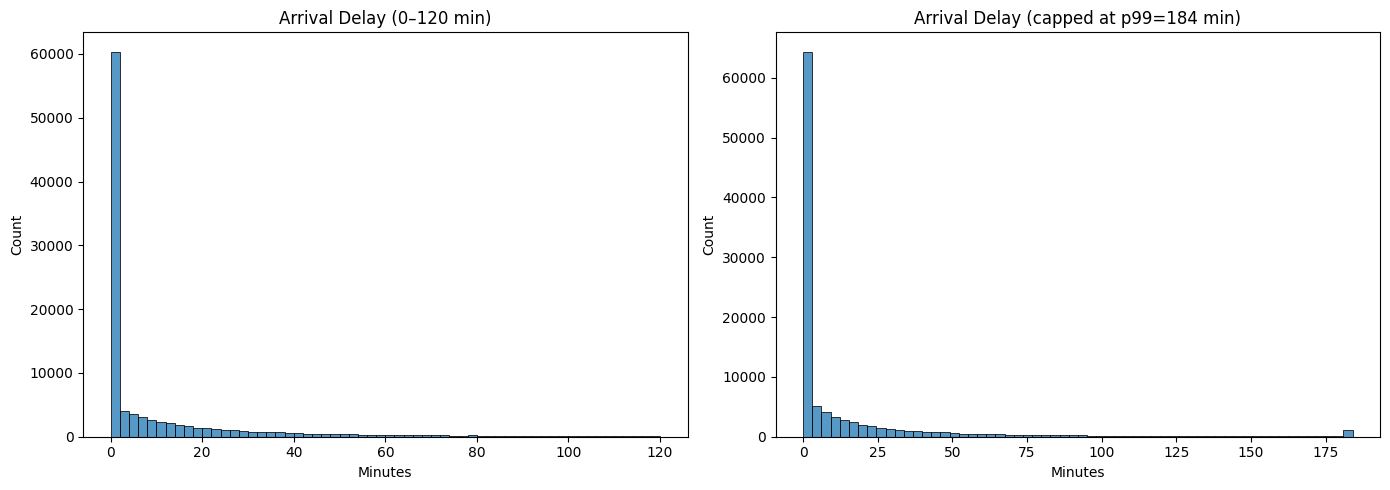

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Zoom 0-120 min (lisible)
sns.histplot(data=df, x="Arrival Delay in Minutes", bins=60, binrange=(0, 120), ax=axes[0])
axes[0].set_title("Arrival Delay (0–120 min)")
axes[0].set_xlabel("Minutes")

# Queue (cap à p99 pour visualiser sans être dominé par les extrêmes)
cap = df["Arrival Delay in Minutes"].quantile(0.99)
sns.histplot(df["Arrival Delay in Minutes"].clip(upper=cap), bins=60)
axes[1].set_title(f"Arrival Delay (capped at p99={cap:.0f} min)")
axes[1].set_xlabel("Minutes")

plt.tight_layout()
plt.show()


Le graphe 1 montre que les retards à l’arrivée sont **très asymétriques** : énorme pic à 0 minute (beaucoup de vols “à l’heure”) puis une longue “queue” vers la droite (quelques vols très en retard).
C’est typique d’une distribution “right-skewed”, où quelques grandes valeurs étirent l’axe et masquent la structure du gros des données si on ne fait pas de zoom/capping.

#### Interprétation du plot gauche (0–120 min)
- Le pic très haut près de 0 confirme qu’une majorité de vols ont un retard d’arrivée nul ou très faible (ce que tu as aussi quantifié avec ~56% de zéros).
- Entre 0 et ~30 minutes, on voit encore beaucoup d’observations, puis la fréquence diminue progressivement : c’est la partie “opérationnel standard” (petites irrégularités).

#### Interprétation du plot droit (cap à p99)
- Ici on cappes au percentile 99 (p99 ≈ 184 min dans tes stats), ce qui évite que les retards extrêmes (jusqu’à ~1584 min) écrasent complètement la visualisation.
- Ce choix est surtout un choix de **visualisation EDA** : il ne supprime pas les données, il permet juste de lire la forme de la distribution sur la zone où se trouvent 99% des vols.

#### Insight
- La distribution des retards à l’arrivée présente un pic majeur à 0 minute et une longue queue à droite, indiquant que la majorité des vols sont ponctuels mais qu’une minorité de vols très perturbés existe.
- Pour rendre la visualisation lisible, on affiche un zoom sur 0–120 minutes et une version cappée au percentile 99 (p99 ≈ 184 min), afin de limiter l’influence visuelle des outliers.


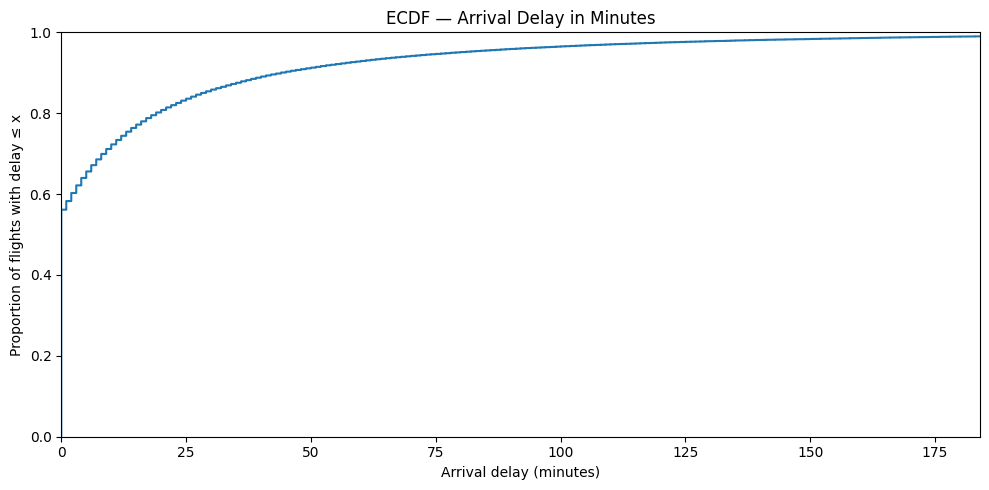

,threshold_min,pct_flights_delay_le_threshold
0,0,0.561413
1,15,0.771850
2,30,0.858467
3,60,0.929272
4,120,0.974738
5,180,0.989565


,percentile,arrival_delay_min
0,0.50,0.0
1,0.75,13.0
2,0.90,44.0
3,0.95,79.0
4,0.99,184.0


In [13]:

x = df["Arrival Delay in Minutes"].dropna()

# 1) Courbe ECDF
plt.figure(figsize=(10,5))
sns.ecdfplot(x=x)
plt.title("ECDF — Arrival Delay in Minutes")
plt.xlabel("Arrival delay (minutes)")
plt.ylabel("Proportion of flights with delay ≤ x")
plt.xlim(0, x.quantile(0.99))  # optionnel: zoom sur 99% des vols
plt.tight_layout()
plt.show()

# 2) Quelques seuils business faciles à commenter
thresholds = [0, 15, 30, 60, 120, 180]
cdf_table = pd.DataFrame({
    "threshold_min": thresholds,
    "pct_flights_delay_le_threshold": [(x <= t).mean() for t in thresholds]
})
display(cdf_table)

# 3) Percentiles (autre lecture, très utilisée en ops)
percentiles = [0.5, 0.75, 0.90, 0.95, 0.99]
q_table = pd.DataFrame({
    "percentile": percentiles,
    "arrival_delay_min": [x.quantile(p) for p in percentiles]
})
display(q_table)


Ponctualité stricte (0 min) : 56.1% des vols arrivent avec 0 minute de retard dans l’échantillon (retard arrivée ≤ 0).
​

Standard airline (≤ 15 min) : 77.2% des vols ont un retard à l’arrivée ≤ 15 minutes (seuil souvent utilisé pour l’on-time performance).
​
​

Cas perturbés : 97.5% des vols ont un retard ≤ 120 minutes, donc ~2.5% dépassent 2h de retard à l’arrivée (événements de disruption).
​

Lecture percentiles (très parlante)
Le P50 = 0 min confirme que la moitié des vols n’ont pas de retard à l’arrivée (au sens de la mesure du dataset).
​

Le P75 = 13 min montre qu’un vol “plutôt mauvais mais courant” reste souvent dans la zone <15 min.
​

Le P95 = 79 min et le P99 = 184 min décrivent la “queue” : les pires 5% dépassent ~1h19, et les pires 1% dépassent ~3h04.
​

Ces indicateurs justifient un design “post-vol” en 2 couches : (1) un traitement standard pour la majorité (≤15 min) et (2) un workflow renforcé de service recovery pour les cas perturbés (ex. >15 min, >60 min, >120 min), d’autant que les retards ont un impact négatif sur la satisfaction dans de nombreuses études

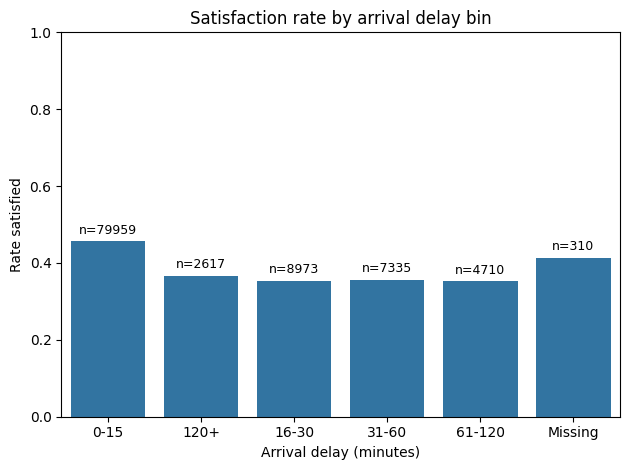

,arr_delay_bin,rate_satisfied,n
0,0-15,0.456496,79959
1,120+,0.365686,2617
2,16-30,0.352725,8973
3,31-60,0.356374,7335
4,61-120,0.352442,4710
5,Missing,0.412903,310


In [14]:
bins = [0, 15, 30, 60, 120,float("inf")]
labels = ["0-15", "16-30", "31-60", "61-120", "120+"]

tmp = df.copy()
tmp["arr_delay_bin"] = pd.cut(
    tmp["Arrival Delay in Minutes"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

tmp["arr_delay_bin"] = tmp["arr_delay_bin"].astype(str)

tmp.loc[tmp["Arrival Delay in Minutes"].isna(), "arr_delay_bin"] = "Missing"

rate = (tmp.groupby("arr_delay_bin")["is_satisfied"]
          .agg(rate_satisfied="mean", n="size")
          .reset_index())
# Pour chaque tranche de retard, calcule :

# rate_satisfied : proportion de clients satisfaits
# n : nombre d'observations dans la tranche

ax = sns.barplot(data=rate, x="arr_delay_bin", y="rate_satisfied")
ax.set_title("Satisfaction rate by arrival delay bin")
ax.set_xlabel("Arrival delay (minutes)")
ax.set_ylabel("Rate satisfied")
ax.set_ylim(0, 1)

# annotations n
for i, row in rate.iterrows():
    ax.text(i, row["rate_satisfied"] + 0.02, f"n={int(row['n'])}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

display(rate)


#### Interprétation
- Les vols avec **0–15 min** de retard ont un taux de “satisfied” de **0.456** (n=79 959), soit le meilleur niveau observé dans ce découpage.
- À partir de **>15 min** de retard, le taux de satisfaction tombe autour de **0.35–0.36** (ex. 16–30: 0.353, 31–60: 0.356, 61–120: 0.352, 120+: 0.366), ce qui suggère un “palier” de dégradation dès que le vol sort de la zone “petit retard tolérable”.
- La catégorie **Missing** (0.413, n=310) est intermédiaire : elle est inférieure au bin 0–15 mais supérieure aux bins >15, ce qui indique que les valeurs manquantes ne se comportent pas comme des retards sévères dans cet échantillon (et justifie de les garder comme catégorie séparée en EDA).

#### Deux remarques importantes (qualité de l’analyse)
- Le fait que “120+” (0.366) soit légèrement au-dessus des bins 16–120 n’implique pas que les très gros retards “améliorent” la satisfaction : c’est souvent un effet de composition (segments/Classes différents, stratégie de compensation, faible n relatif) et il faudra confirmer avec une segmentation par `Class` / `Type of Travel`.
- Comme le dataset est post-vol et orienté enquête, le retard est un driver majeur mais pas unique : tes analyses précédentes montrent déjà que des variables d’expérience comme `Online boarding` séparent fortement satisfaits vs non satisfaits.

#### Insight
À partir de 15 minutes de retard à l’arrivée, la satisfaction chute d’environ 10 points (de ~0.456 à ~0.35–0.36), ce qui motive une règle opérationnelle simple : déclencher un service recovery prioritaire sur les vols >15 min, puis affiner par segment.

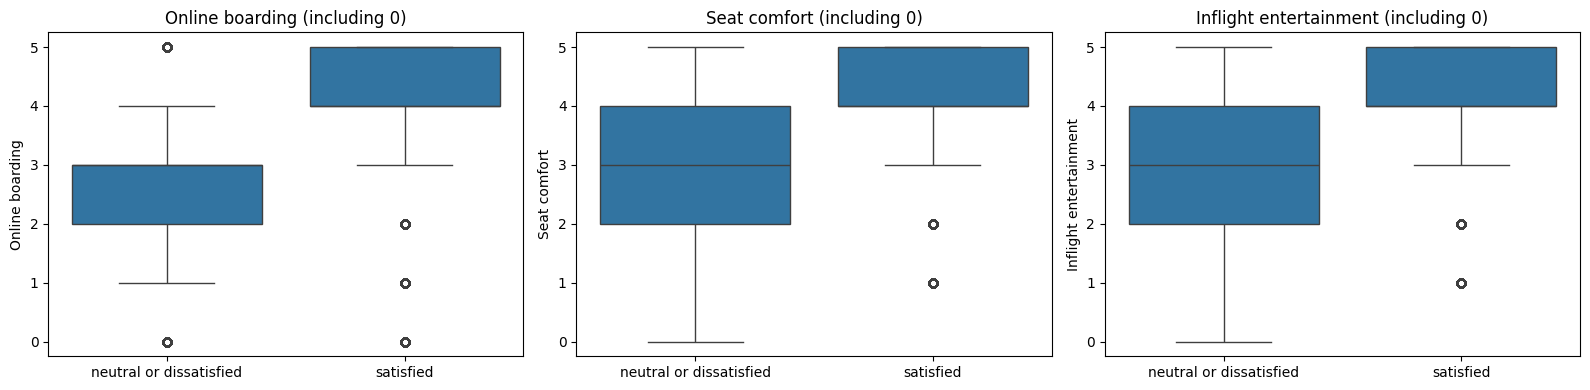

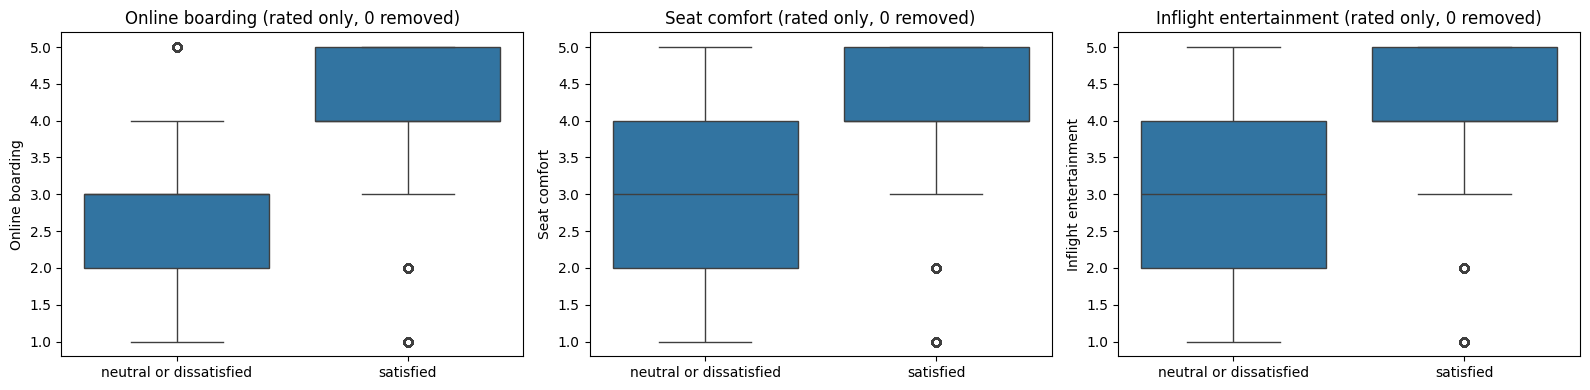

In [15]:
top_features = ["Online boarding", "Seat comfort", "Inflight entertainment"]

# A) Avec les zéros (vue brute)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, top_features):
    sns.boxplot(data=df, x="satisfaction", y=col, ax=ax)
    ax.set_title(f"{col} (including 0)")
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

# B) Sans les zéros (vue 'rated only')
df_rated = df.copy()
for col in top_features:
    df_rated = df_rated[df_rated[col] != 0]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, top_features):
    sns.boxplot(data=df_rated, x="satisfaction", y=col, ax=ax)
    ax.set_title(f"{col} (rated only, 0 removed)")
    ax.set_xlabel("")
plt.tight_layout()
plt.show()


Online boarding ressort comme un levier majeur : quand l’embarquement en ligne se passe mal (notes basses), la probabilité d’insatisfaction augmente fortement, même si d’autres aspects sont corrects.
​
Seat comfort et Inflight entertainment confirment un driver “expérience cabine” : l’insatisfaction est associée à un niveau plus bas et plus variable de ces notes.

Après exclusion des valeurs 0 (considérées comme ‘non applicable/non noté’), les variables Online boarding, Seat comfort et Inflight entertainment conservent une forte capacité de séparation entre passagers satisfaits et non satisfaits, ce qui confirme qu’il s’agit de drivers robustes dans cette enquête post-vol.
​

Le très faible recouvrement des distributions, en particulier pour Online boarding, suggère que l’expérience d’embarquement digital/on-site est un levier prioritaire pour l’amélioration continue et un excellent signal pour un système de service recovery post-vol.

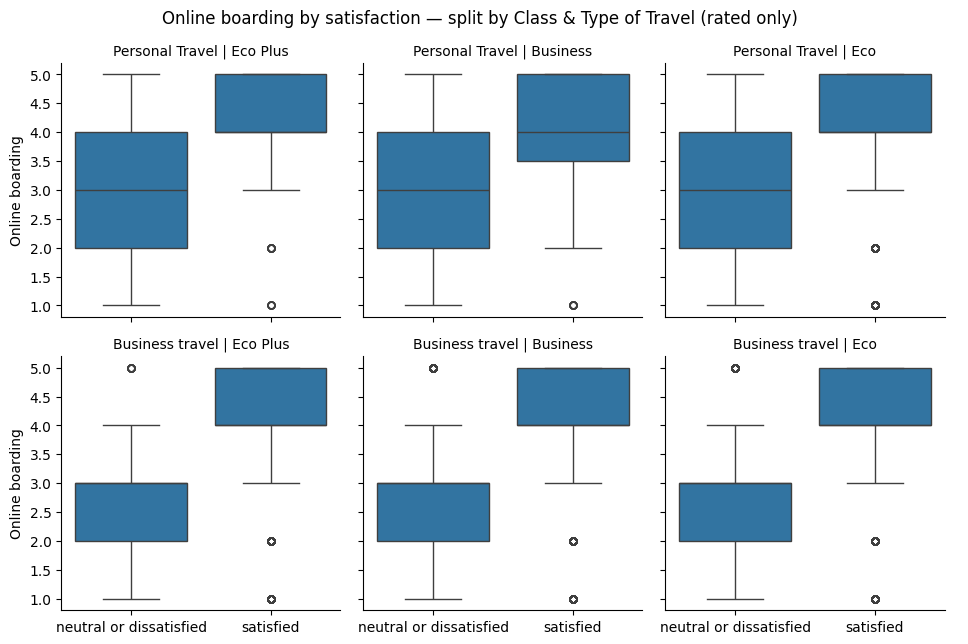

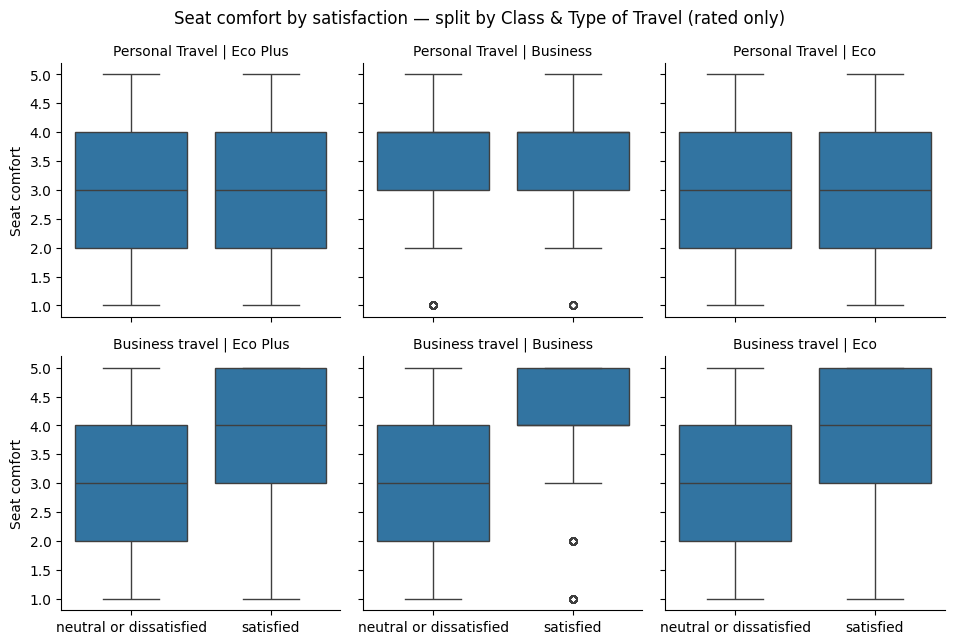

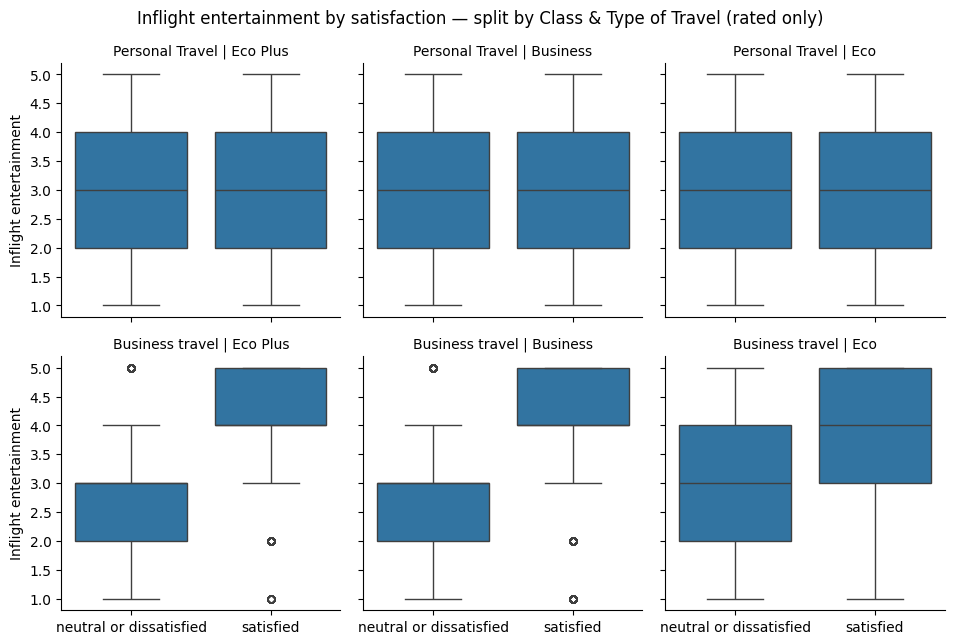

In [16]:

df_rated = df.copy()

# Option: enlever les 0 pour ces 3 features (rated only)
for col in top_features:
    df_rated = df_rated[df_rated[col] != 0]

# Boxplots facettés: lignes = Type of Travel, colonnes = Class
for col in top_features:
    g = sns.catplot(
        data=df_rated,
        x="satisfaction",
        y=col,
        row="Type of Travel",
        col="Class",
        kind="box",
        height=3.2,
        aspect=1
    )
    g.set_titles(row_template="{row_name}", col_template="{col_name}")
    g.set_axis_labels("", col)
    g.fig.suptitle(f"{col} by satisfaction — split by Class & Type of Travel (rated only)", y=1.03)
    plt.show()


**Online boarding** discrimine fortement satisfaits vs non satisfaits dans tous les segments (Eco/Eco+/Business × Personal/Business travel), ce qui en fait un candidat prioritaire pour l’amélioration continue.
​

L’écart est visible même après suppression des notes 0 (considérées comme non notées/non applicables), donc l’effet observé est robuste.
​
On observe aussi quelques valeurs atypiques (outliers) : certains passagers se déclarent satisfaits malgré une mauvaise note d’Online boarding, ce qui rappelle que la satisfaction est multi-factorielle.



 Pour **Seat confort** l’effet “driver” existe, mais il n’est pas aussi uniforme que pour Online boarding : la séparation entre satisfaits et non satisfaits est surtout visible sur la ligne Business travel, alors qu’elle est beaucoup plus faible sur Personal Travel.
​

Ce que montre le graphe
En Business travel (ligne du bas), la boîte “satisfied” est clairement plus haute que “neutral or dissatisfied” dans les 3 classes (Eco/Eco Plus/Business), ce qui suggère que le confort siège est un facteur important de satisfaction pour les voyageurs business.
​

En Personal Travel (ligne du haut), les boîtes des deux classes se chevauchent beaucoup plus (médianes proches), ce qui indique que le confort siège discrimine moins la satisfaction globale dans ce segment (ou que d’autres facteurs dominent).
​

Rappel lecture : la ligne dans la boîte = médiane et la boîte = intervalle interquartile (milieu 50%), donc quand les boîtes se chevauchent fortement, la variable sépare moins bien les groupes.
​

Le driver Seat comfort est segment-dépendant : très discriminant en Business travel, plus faible en Personal Travel, ce qui plaide pour des actions ciblées (cabine/sièges) priorisées sur les flux business.


Pour **Inflight entertainment**, on retrouve le même schéma que pour “Seat comfort” : l’effet est très fort sur les voyageurs Business travel, et beaucoup plus faible sur Personal Travel.
​

En Business travel (ligne du bas), les distributions “satisfied” sont clairement décalées vers le haut (souvent autour de 4–5) par rapport aux “neutral or dissatisfied” (plutôt 2–3), quelle que soit la Class.
​

En Personal Travel (ligne du haut), les deux boîtes se chevauchent beaucoup plus : l’entertainment discrimine moins la satisfaction globale sur ce segment.
​

Insight principal : l’entertainment semble être un “délighter” surtout pour le business travel (attentes plus élevées, sensibilité plus forte aux irritants cabine), tandis que pour le personal travel d’autres facteurs dominent davantage la satisfaction.


In [17]:
df.columns

Index(['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class',
       'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction', 'is_satisfied'],
      dtype='object')

In [18]:
dfrated = df[df["Online boarding"] != 0].copy()  # rated only

dfrated["ob_band"] = pd.cut(dfrated["Online boarding"], bins=[0,3,5], labels=["<=3", ">=4"], include_lowest=True)

seg = (dfrated.groupby(["Type of Travel","Class","ob_band"])["is_satisfied"]
         .agg(rate_satisfied="mean", n="size")
         .reset_index())

display(seg)


,Type of Travel,Class,ob_band,rate_satisfied,n
0,Business travel,Business,<=3,0.311075,14601
1,Business travel,Business,>=4,0.902971,32413
2,Business travel,Eco,<=3,0.092374,12785
3,Business travel,Eco,>=4,0.638611,6998
4,Business travel,Eco Plus,<=3,0.128532,2194
5,Business travel,Eco Plus,>=4,0.724555,1572
6,Personal Travel,Business,<=3,0.056377,1082
7,Personal Travel,Business,>=4,0.176871,1029
8,Personal Travel,Eco,<=3,0.020172,17004
9,Personal Travel,Eco,>=4,0.232642,8339



On a 2 groupes :
- `ob_band = <=3` (mauvaise / moyenne expérience d’online boarding)  
- `ob_band = >=4` (bonne expérience)  
et on regarde `rate_satisfied` dans chaque segment.

#### Résultats clés
- Dans **tous les segments**, passer de `<=3` à `>=4` augmente fortement le taux de satisfaction, ce qui confirme que **Online boarding est un driver robuste** de la satisfaction globale.

- L’effet est particulièrement spectaculaire sur **Business travel** : par exemple en *Business travel | Business*, on passe de **0.311** (n=14 601) à **0.903** (n=32 413).  

- Même en *Business travel | Eco*, l’écart est massif : **0.092** (n=12 785) vs **0.639** (n=6 998), ce qui suggère que l’embarquement digital/gate process est critique même quand le produit cabine est plus basic.

#### Lecture métier
- Online boarding est un levier *cross-segment* : quand l’expérience est notée ≥4, la probabilité d’être satisfait grimpe partout, donc c’est un bon candidat pour une initiative globale (app/check-in, stabilité, UX, info gate, files prioritaires).

- Les voyageurs **Personal Travel** restent globalement moins satisfaits, même quand Online boarding est bon (ex. Eco: 0.233), ce qui indique qu’une partie de leur satisfaction dépend d’autres dimensions (prix perçu, confort cabine, divertissement, etc.) et doit être adressée par d’autres chantiers.

#### Deux points à noter
- Les tailles d’échantillon (`n`) sont très différentes selon segment (ex. Personal Travel | Business est petit), donc il faudrait interpréter les plus petits segments avec prudence.

- Cette analyse est descriptive (corrélation), donc la suite logique serait de contrôler les autres facteurs via un modèle (logistic/GBM) et de vérifier que l’effet reste fort.


In [19]:
def band_satisfaction_rate(df, feature, thr=3, group_cols=("Type of Travel","Class")):
    tmp = df[df[feature] != 0].copy()  # rated only
    tmp["band"] = pd.cut(tmp[feature], bins=[0, thr, 5], labels=[f"<= {thr}", f">= {thr+1}"], include_lowest=True)

    out = (tmp.groupby(list(group_cols) + ["band"])["is_satisfied"]
             .agg(rate_satisfied="mean", n="size")
             .reset_index()
             .sort_values(list(group_cols) + ["band"]))
    return out


In [20]:
seat_table = band_satisfaction_rate(df, "Seat comfort", thr=3)
display(seat_table)

,Type of Travel,Class,band,rate_satisfied,n
0,Business travel,Business,<= 3,0.382856,14687
1,Business travel,Business,>= 4,0.871207,32820
2,Business travel,Eco,<= 3,0.190036,11682
3,Business travel,Eco,>= 4,0.440816,8575
4,Business travel,Eco Plus,<= 3,0.206190,2197
5,Business travel,Eco Plus,>= 4,0.636149,1693
6,Personal Travel,Business,<= 3,0.105263,912
7,Personal Travel,Business,>= 4,0.134940,1245
8,Personal Travel,Eco,<= 3,0.099734,14308
9,Personal Travel,Eco,>= 4,0.104598,12180


Chez les voyageurs business, quand le siège est noté ≥4, la probabilité d’être satisfait augmente fortement, donc Seat comfort est un levier prioritaire pour ce segment.

Pour les voyageurs loisirs, la satisfaction globale semble moins pilotée par le confort siège (ou bien l’effet est masqué par d’autres facteurs plus dominants comme retards, parcours, service, etc.).

Le confort siège est un driver segmenté : énorme levier sur Business travel (jusqu’à +49 points de satisfaction quand la note passe à ≥4), mais quasi inutile sur Personal travel, donc les investissements cabine doivent être priorisés sur les flux business.

In [21]:
ent_table = band_satisfaction_rate(df, "Inflight entertainment", thr=3)
display(ent_table)


,Type of Travel,Class,band,rate_satisfied,n
0,Business travel,Business,<= 3,0.402205,16867
1,Business travel,Business,>= 4,0.895446,30635
2,Business travel,Eco,<= 3,0.146799,11308
3,Business travel,Eco,>= 4,0.485133,8946
4,Business travel,Eco Plus,<= 3,0.138192,2113
5,Business travel,Eco Plus,>= 4,0.698646,1772
6,Personal Travel,Business,<= 3,0.124809,1306
7,Personal Travel,Business,>= 4,0.118684,851
8,Personal Travel,Eco,<= 3,0.102024,15565
9,Personal Travel,Eco,>= 4,0.101895,10923


Pour les voyageurs business, une bonne note d’entertainment (≥4) est fortement associée à la satisfaction globale, donc c’est un levier cabine pertinent sur ces flux.

Côté loisirs, l’entertainment ne semble pas être le facteur principal qui fait basculer la satisfaction dans ce dataset (retards, parcours, service, prix perçu peuvent dominer)

Inflight entertainment est un driver segmenté : gros impact sur Business travel (jusqu’à +56 points en Eco Plus), mais impact quasi nul sur Personal Travel ; les investissements IFE doivent donc être priorisés sur les flux business/premium plutôt que généralisés.

In [22]:
def band_table(feature, thr=3):
    tmp = df[df[feature] != 0].copy()  # rated only (0 = N/A)
    tmp["band"] = pd.cut(tmp[feature], bins=[0, thr, 5], labels=[f"<= {thr}", f">= {thr+1}"], include_lowest=True)
    out = (tmp.groupby(["Type of Travel","Class","band"])["is_satisfied"]
             .agg(rate_satisfied="mean", n="size")
             .reset_index())
    return out

for feat in ["Inflight wifi service", "Ease of Online booking", "Gate location"]:
    display(feat)
    display(band_table(feat))


'Inflight wifi service'

,Type of Travel,Class,band,rate_satisfied,n
0,Business travel,Business,<= 3,0.611908,29359
1,Business travel,Business,>= 4,0.883006,16223
2,Business travel,Eco,<= 3,0.046521,12833
3,Business travel,Eco,>= 4,0.713026,7032
4,Business travel,Eco Plus,<= 3,0.068854,2164
5,Business travel,Eco Plus,>= 4,0.786432,1592
6,Personal Travel,Business,<= 3,0.000000,1634
7,Personal Travel,Business,>= 4,0.448936,470
8,Personal Travel,Eco,<= 3,0.000000,20697
9,Personal Travel,Eco,>= 4,0.411877,5254


'Ease of Online booking'

,Type of Travel,Class,band,rate_satisfied,n
0,Business travel,Business,<= 3,0.667565,26727
1,Business travel,Business,>= 4,0.775330,18792
2,Business travel,Eco,<= 3,0.197753,13264
3,Business travel,Eco,>= 4,0.466667,6450
4,Business travel,Eco Plus,<= 3,0.336066,2318
5,Business travel,Eco Plus,>= 4,0.442727,1423
6,Personal Travel,Business,<= 3,0.012187,1559
7,Personal Travel,Business,>= 4,0.387879,495
8,Personal Travel,Eco,<= 3,0.007769,19436
9,Personal Travel,Eco,>= 4,0.357027,5543


'Gate location'

,Type of Travel,Class,band,rate_satisfied,n
0,Business travel,Business,<= 3,0.715944,29026
1,Business travel,Business,>= 4,0.726909,18481
2,Business travel,Eco,<= 3,0.295160,12417
3,Business travel,Eco,>= 4,0.297832,7840
4,Business travel,Eco Plus,<= 3,0.386198,2333
5,Business travel,Eco Plus,>= 4,0.403982,1557
6,Personal Travel,Business,<= 3,0.121150,1461
7,Personal Travel,Business,>= 4,0.125000,696
8,Personal Travel,Eco,<= 3,0.102805,17898
9,Personal Travel,Eco,>= 4,0.100233,8590


Chez les voyageurs business, une bonne note wifi (≥4) est fortement associée à une satisfaction globale plus élevée, ce qui est cohérent avec l’idée que la connectivité est importante pour l’expérience (notamment pour travailler).

Ease of Online booking est un driver très fort sur Personal Travel (delta ~ +0.32 à +0.38 selon la cabine) et un driver modéré sur Business travel, surtout en Eco.

Même si Gate location fait partie des variables avec une moyenne relativement faible dans les ratings, son impact sur la satisfaction globale est très faible : les taux de satisfaction restent presque identiques entre <=3 et >=4 dans tous les segments.
​
Gate location est plutôt un irritant ‘mineur’ (souvent mentionné) qu’un levier prioritaire pour faire bouger la satisfaction globale, donc à traiter après les drivers à fort delta.

- Inflight wifi service : driver massif (surtout Personal Travel + Business travel Eco/Eco Plus).
- Ease of Online booking : driver massif (surtout Personal Travel).
- Gate location : irritant mais faible impact (pas prioritaire).

**Conclusion**:
On distingue ce qui est mal noté’ de ‘ce qui change vraiment la satisfaction’. Exemple : Gate location est mal noté, mais l’améliorer ne bouge presque pas le taux de satisfaction, donc ce n’est pas une priorité ROI.


##### Digging on the binary of some wifi notes

In [23]:
tmp = df[df["Inflight wifi service"] != 0].copy()
ct = pd.crosstab(
    [tmp["Type of Travel"], tmp["Inflight wifi service"]],
    tmp["satisfaction"],
    normalize="index"
)
display(ct)


satisfaction                           neutral or dissatisfied  satisfied
Type of Travel  Inflight wifi service                                    
Business travel 1                                     0.517494   0.482506
                2                                     0.604860   0.395140
                3                                     0.596589   0.403411
                4                                     0.282717   0.717283
                5                                     0.010425   0.989575
Personal Travel 1                                     1.000000   0.000000
                2                                     1.000000   0.000000
                3                                     1.000000   0.000000
                4                                     0.740567   0.259433
                5                                     0.000000   1.000000

In [24]:
tmp = df[df["Inflight wifi service"] != 0].copy()
counts = pd.crosstab(tmp["Type of Travel"], tmp["Inflight wifi service"])
display(counts)


Inflight wifi service,1,2,3,4,5
Type of Travel,,,,,
Business travel,12033,16255,16068,14679,10168
Personal Travel,5807,9575,9800,5115,1301


**En Personal Travel**, la note wifi est quasi “binaire” : pour des volumes significatifs, wifi=1/2/3 correspond à 0% de satisfaits, tandis que wifi=5 correspond à 100% de satisfaits.
​

**En Business travel**, la relation est plus progressive : la satisfaction augmente de façon nette entre wifi=3 (40.3% satisfaits) et wifi=4 (71.7%), puis devient quasi certaine à wifi=5 (99.0%).
​

**Conclusion EDA** : Inflight wifi service est à la fois un top irritant (moyenne basse dans tes stats descriptives) et un driver majeur, avec une sensibilité particulièrement forte sur le segment Personal Travel.
​

**Point “data critique”**
Même si les effectifs sont élevés, une polarisation aussi parfaite (0% satisfaits) peut aussi indiquer un effet de construction du dataset (ex. biais de réponse à la question wifi, ou population spécifique qui note le wifi uniquement quand elle est très mécontente).

Le dataset provient d’une enquête de satisfaction et a été mis à disposition sur Kaggle pour un usage de classification; l’historique exact des transformations amont n’est pas documenté.
Certaines relations sont extrêmement polarisées (ex. wifi vs satisfaction sur Personal Travel), ce qui peut refléter soit un signal réel très fort, soit un artefact de sélection/labeling; ces résultats doivent être interprétés comme descriptifs et à revalider sur des données opérationnelles de l’airline.
​

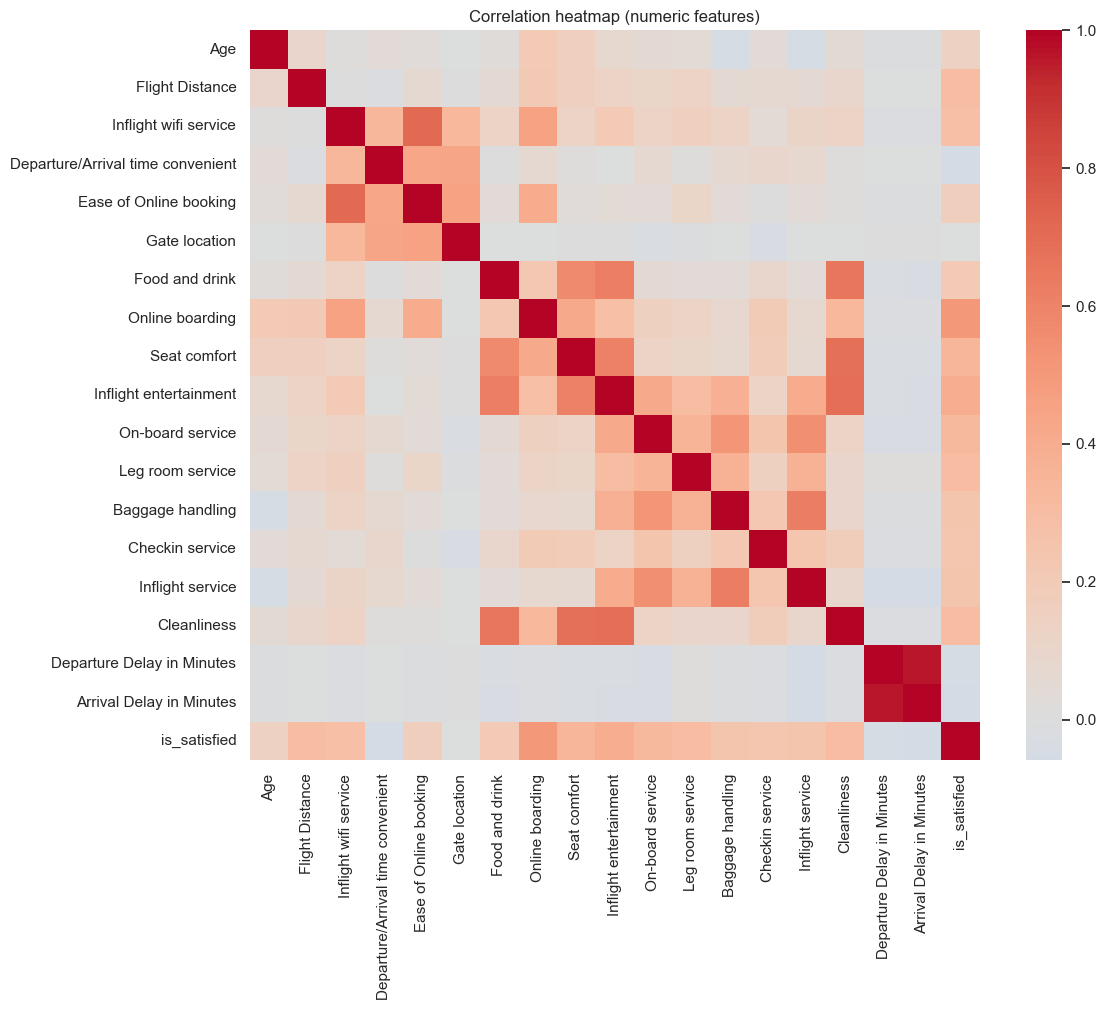

In [25]:
sns.set_theme(style="whitegrid")

# garder uniquement les colonnes numériques
num_df = df.select_dtypes(include=["int64", "float64"])

# corrélation (Pearson) en ignorant les NaN
corr = num_df.corr(numeric_only=True)

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True)
plt.title("Correlation heatmap (numeric features)")
plt.tight_layout()
plt.show()

Pearson corr(dep_delay, arr_delay) = 0.965


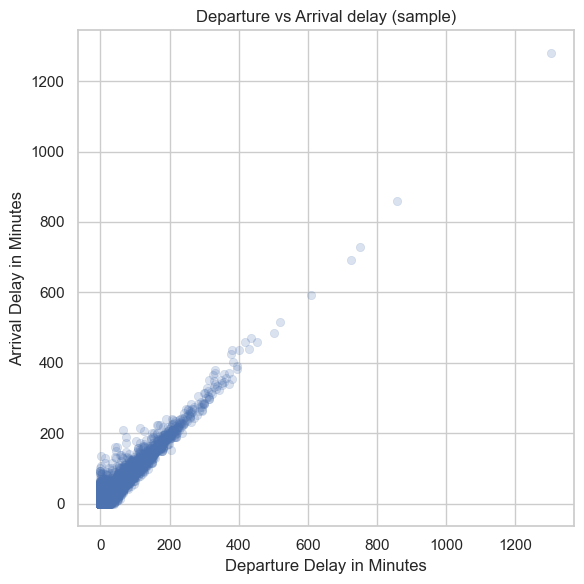

In [26]:
delay_cols = ["Departure Delay in Minutes", "Arrival Delay in Minutes"]
tmp = df[delay_cols].dropna()

r = tmp["Departure Delay in Minutes"].corr(tmp["Arrival Delay in Minutes"])
print(f"Pearson corr(dep_delay, arr_delay) = {r:.3f}")

plt.figure(figsize=(6,6))
sns.scatterplot(
    data=tmp.sample(min(len(tmp), 20000), random_state=42),
    x="Departure Delay in Minutes",
    y="Arrival Delay in Minutes",
    alpha=0.2,
    edgecolor=None
)
plt.title("Departure vs Arrival delay (sample)")
plt.tight_layout()
plt.show()


Le retard au départ et le retard à l’arrivée sont très fortement corrélés (Pearson r=0.965), ce qui est cohérent avec un phénomène de propagation du retard : un vol qui part en retard arrive souvent en retard.
​
Cette redondance implique que, pour des modèles linéaires, il peut y avoir un risque de multicolinéarité; pour des modèles arbres/boosting l’impact est moindre, mais l’interprétation peut gagner à utiliser une variable dérivée delay_delta = Arrival - Departure (capacité à rattraper ou accumuler du retard)

In [27]:
df["delay_delta"] = df["Arrival Delay in Minutes"] - df["Departure Delay in Minutes"]
display(df["delay_delta"].describe())


count    103594.000000
mean          0.430739
std          10.108148
min         -51.000000
25%          -2.000000
50%           0.000000
75%           0.000000
max         234.000000
Name: delay_delta, dtype: float64

Utile : est-ce que le vol rattrape du retard en route ou au contraire en prend.
​

Interprétation “notebook-ready” de delay_delta
La médiane est 0 et le 75e percentile est 0, ce qui signifie qu’au moins 75% des vols ont un delay_delta nul ou négatif (le retard n’augmente pas entre départ et arrivée, et il est souvent stable).
​

Le 25e percentile est -2 et le minimum est -51 : une partie des vols “rattrapent” du retard (arrivent moins en retard que le départ), ce qui est cohérent avec de la récupération en vol ou au sol arrivée (ex. block time).
​

Le maximum est 234 : il existe des cas où le vol accumule beaucoup de retard après le départ (congestion arrivée, météo, attente de stand, etc.), donc delay_delta capture une dimension différente des retards bruts.


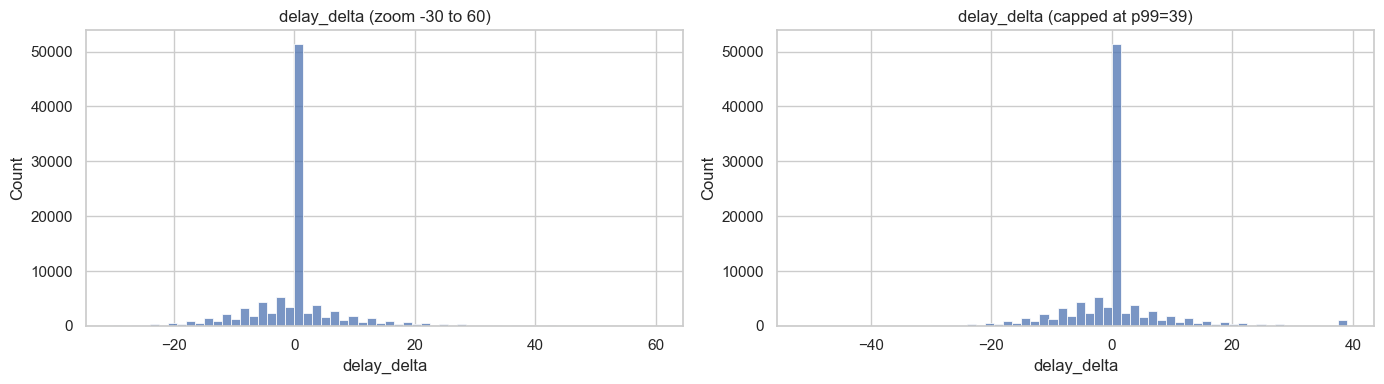

In [29]:
cap = df["delay_delta"].quantile(0.99)

fig, ax = plt.subplots(1, 2, figsize=(14,4))
sns.histplot(df["delay_delta"], bins=60, binrange=(-30, 60), ax=ax[0])
ax[0].set_title("delay_delta (zoom -30 to 60)")

sns.histplot(df["delay_delta"].clip(upper=cap), bins=60)
ax[1].set_title(f"delay_delta (capped at p99={cap:.0f})")

plt.tight_layout()
plt.show()


Le pic massif autour de 0 montre que, dans la majorité des cas, le retard à l’arrivée est proche du retard au départ (cohérent avec la forte corrélation 0.965 entre les deux retards).
​
Dans le zoom (-30 à 60), on voit des valeurs négatives (vols qui rattrapent du retard) et positives (vols qui accumulent du retard), avec une distribution légèrement étirée du côté positif.
​
Le cap p99 à 39 minutes indique que 99% des vols ont un delay_delta ≤ 39, donc les valeurs très positives (jusqu’à 234 dans ton descriptif) sont des événements rares mais importants (congestion arrivée, aléas météo/ATC, etc.).

**Resumé:**
La plupart des vols ne “créent” pas de retard supplémentaire après le départ, mais une minorité en accumule (et une autre en rattrape un peu).
​

In [30]:
df_ob = df[df["Online boarding"] != 0].copy()

case_A = df_ob[(df_ob["is_satisfied"] == 1) & (df_ob["Online boarding"] <= 2)]
case_B = df_ob[(df_ob["is_satisfied"] == 0) & (df_ob["Online boarding"] >= 4)]

print("Case A (satisfied & online boarding<=2):", case_A.shape[0])
print("Case B (not satisfied & online boarding>=4):", case_B.shape[0])


Case A (satisfied & online boarding<=2): 3492
Case B (not satisfied & online boarding>=4): 14252


In [31]:
num_cols = ["Age", "Flight Distance", "Departure Delay in Minutes", "Arrival Delay in Minutes"]
rating_cols = [c for c in df.columns if c not in
               ["satisfaction","is_satisfied","Gender","Customer Type","Type of Travel","Class"] + num_cols]

def summarize(group, name):
    out = {}
    out["group"] = name
    out["n"] = len(group)
    out["pct_business_class"] = (group["Class"] == "Business").mean()
    out["pct_business_travel"] = (group["Type of Travel"] == "Business travel").mean()
    out["mean_arr_delay"] = group["Arrival Delay in Minutes"].mean()
    out["mean_dep_delay"] = group["Departure Delay in Minutes"].mean()
    # “compensation” via autres notes: top 5 moyennes
    means = group[rating_cols].replace(0, pd.NA).mean().sort_values(ascending=False).head(5)
    out["top5_ratings"] = means
    return out

sum_A = summarize(case_A, "A: satisfied & online_boarding<=2")
sum_B = summarize(case_B, "B: not_satisfied & online_boarding>=4")
display(sum_A)
display(sum_B)


{'group': 'A: satisfied & online_boarding<=2',
 'n': 3492,
 'pct_business_class': np.float64(0.6955899198167239),
 'pct_business_travel': np.float64(0.9369988545246277),
 'mean_arr_delay': np.float64(14.953775480907264),
 'mean_dep_delay': np.float64(14.616265750286368),
 'top5_ratings': Inflight service          3.989691
 Baggage handling          3.985682
 Leg room service          3.953682
 On-board service           3.92583
 Inflight entertainment    3.711913
 dtype: object}

{'group': 'B: not_satisfied & online_boarding>=4',
 'n': 14252,
 'pct_business_class': np.float64(0.28010103845074374),
 'pct_business_travel': np.float64(0.4285012629806343),
 'mean_arr_delay': np.float64(18.52920478536242),
 'mean_dep_delay': np.float64(17.747333707549817),
 'top5_ratings': Online boarding                       4.18636
 Departure/Arrival time convenient    3.626058
 Seat comfort                         3.575398
 Cleanliness                          3.265245
 Ease of Online booking               3.226633
 dtype: object}

Un sous-groupe non négligeable reste satisfait malgré une mauvaise expérience d’online boarding; ce sont surtout des voyageurs business/premium, et leur satisfaction semble compensée par une forte qualité perçue du service à bord et des éléments cabine.

Une bonne expérience d’online boarding n’est pas suffisante pour garantir la satisfaction : un large groupe reste insatisfait malgré une note ≥4, probablement parce que d’autres dimensions (cabine/retards/digital hors boarding) tirent l’expérience globale vers le bas.

In [32]:
df_w = df[df["Inflight wifi service"] != 0].copy()

W_A = df_w[(df_w["is_satisfied"] == 1) & (df_w["Inflight wifi service"] <= 3)]
W_B = df_w[(df_w["is_satisfied"] == 0) & (df_w["Inflight wifi service"] >= 4)]

W_C = df_w[(df_w["is_satisfied"] == 1) & (df_w["Inflight wifi service"] == 1)]
W_D = df_w[(df_w["is_satisfied"] == 0) & (df_w["Inflight wifi service"] == 5)]

print("W_A (satisfied & wifi<=3):", len(W_A))
print("W_B (not satisfied & wifi>=4):", len(W_B))
print("W_C (satisfied & wifi==1):", len(W_C))
print("W_D (not satisfied & wifi==5):", len(W_D))


W_A (satisfied & wifi<=3): 18711
W_B (not satisfied & wifi>=4): 8044
W_C (satisfied & wifi==1): 5806
W_D (not satisfied & wifi==5): 106


In [33]:
num_cols = ["Age", "Flight Distance", "Departure Delay in Minutes", "Arrival Delay in Minutes"]
rating_cols = [c for c in df.columns if c not in
               ["satisfaction","is_satisfied","Gender","Customer Type","Type of Travel","Class"] + num_cols]

def summarize(group, name):
    out = {}
    out["group"] = name
    out["n"] = len(group)
    out["pct_business_class"] = (group["Class"] == "Business").mean()
    out["pct_business_travel"] = (group["Type of Travel"] == "Business travel").mean()
    out["mean_arr_delay"] = group["Arrival Delay in Minutes"].mean()
    # top notes hors wifi
    means = (group[rating_cols]
             .drop(columns=["Inflight wifi service"], errors="ignore")
             .replace(0, pd.NA)
             .mean()
             .sort_values(ascending=False)
             .head(6))
    out["top6_other_ratings"] = means
    return out

display(summarize(W_A, "W_A: satisfied & wifi<=3"))
display(summarize(W_B, "W_B: not_satisfied & wifi>=4"))


{'group': 'W_A: satisfied & wifi<=3',
 'n': 18711,
 'pct_business_class': np.float64(0.960130404574849),
 'pct_business_travel': np.float64(1.0),
 'mean_arr_delay': np.float64(13.076325239856354),
 'top6_other_ratings': Seat comfort              4.157501
 Online boarding           4.137887
 Inflight entertainment    4.135802
 Baggage handling            4.1156
 Inflight service          4.113089
 On-board service          4.040938
 dtype: object}

{'group': 'W_B: not_satisfied & wifi>=4',
 'n': 8044,
 'pct_business_class': np.float64(0.2681501740427648),
 'pct_business_travel': np.float64(0.5290900049726505),
 'mean_arr_delay': np.float64(16.269417778331878),
 'top6_other_ratings': Online boarding                      3.791703
 Ease of Online booking               3.698323
 Baggage handling                     3.595848
 Inflight service                     3.576952
 Departure/Arrival time convenient      3.5105
 Leg room service                     3.338529
 dtype: object}

Le wifi peut être compensé : une fraction importante de passagers reste satisfaite malgré un wifi ≤3, mais ce sont quasi exclusivement des voyageurs business en cabine Business, avec des scores très élevés sur confort et service.

Un bon wifi n’est pas suffisant pour garantir la satisfaction : un groupe significatif reste insatisfait malgré wifi ≥4, surtout hors Business class, ce qui confirme une satisfaction multi-factorielle.

La crosstab “Personal Travel” montrait 0% de satisfaits pour wifi=1/2/3, et tes contradictions montrent que les satisfaits wifi<=3 existent mais sont 100% Business travel : donc l’effet ‘deal-breaker’ du wifi semble surtout vrai côté Personal Travel, alors que côté Business/premium il est souvent compensé.


In [34]:
features = [
    "Online boarding",
    "Seat comfort",
    "Inflight entertainment",
    "Inflight wifi service",
    "Ease of Online booking",
    "Gate location"
]

def irritant_driver_table(data, feats, thr=3):
    rows = []
    for f in feats:
        tmp = data[data[f] != 0].copy()  # rated only
        mean_score = tmp[f].mean()

        tmp["band"] = pd.cut(tmp[f], bins=[0, thr, 5], labels=[f"<= {thr}", f">= {thr+1}"], include_lowest=True)
        grp = (tmp.groupby("band")["is_satisfied"]
                 .agg(rate="mean", n="size")
                 .to_dict())

        rate_low = grp["rate"].get(f"<= {thr}", np.nan)
        rate_high = grp["rate"].get(f">= {thr+1}", np.nan)

        rows.append({
            "feature": f,
            "mean_score_rated": mean_score,
            "rate_satisfied_<=3": rate_low,
            "rate_satisfied_>=4": rate_high,
            "delta_driver": rate_high - rate_low
        })

    out = pd.DataFrame(rows).sort_values("delta_driver", ascending=False)
    return out

# Global
global_id = irritant_driver_table(df, features, thr=3)
display(global_id)

# Par segment Type of Travel
for seg in df["Type of Travel"].unique():
    seg_df = df[df["Type of Travel"] == seg]
    display(seg, irritant_driver_table(seg_df, features, thr=3))


,feature,mean_score_rated,rate_satisfied_<=3,rate_satisfied_>=4,delta_driver
0,Online boarding,3.328147,0.129017,0.723128,0.594110
3,Inflight wifi service,2.813712,0.269076,0.742699,0.473623
2,Inflight entertainment,3.358610,0.216754,0.628688,0.411934
1,Seat comfort,3.439429,0.218731,0.601631,0.382900
4,Ease of Online booking,2.881328,0.324691,0.616869,0.292178
5,Gate location,2.976911,0.420592,0.455136,0.034544


'Personal Travel'

,feature,mean_score_rated,rate_satisfied_<=3,rate_satisfied_>=4,delta_driver
3,Inflight wifi service,2.573644,0.000000,0.409601,0.409601
4,Ease of Online booking,2.625530,0.007768,0.356223,0.348455
0,Online boarding,2.919096,0.021840,0.223694,0.201854
1,Seat comfort,3.194797,0.098994,0.104707,0.005713
2,Inflight entertainment,3.063692,0.102288,0.100806,-0.001483
5,Gate location,2.918416,0.102786,0.099357,-0.003429


'Business travel'

,feature,mean_score_rated,rate_satisfied_<=3,rate_satisfied_>=4,delta_driver
0,Online boarding,3.507348,0.203009,0.850987,0.647978
2,Inflight entertainment,3.491367,0.288431,0.798249,0.509818
1,Seat comfort,3.549530,0.290415,0.776318,0.485903
3,Inflight wifi service,2.923327,0.421837,0.828712,0.406875
4,Ease of Online booking,2.994230,0.502115,0.682918,0.180802
5,Gate location,3.003238,0.579016,0.588206,0.009190


#### Global (tous passagers)
- **Top driver #1 : Online boarding** avec \(\Delta\) satisfaction de **+0.59** (0.13 → 0.72) ; c’est le levier le plus puissant et actionnable (digital + process aeroport).
- **Driver #2 : Inflight wifi service** \(\Delta\) **+0.47** (0.27 → 0.74) avec un score moyen bas (**2.81**), donc c’est un **quick win** typique : irritant ET fortement lié à la satisfaction.
- **Drivers suivants : Inflight entertainment** \(\Delta\) **+0.41** et **Seat comfort** \(\Delta\) **+0.38** ; ce sont des drivers “produit cabine” qui demandent souvent plus d’investissement (hard/soft product) que le digital.
- **Gate location** a un \(\Delta\) quasi nul (**+0.03**), donc irritant potentiel mais **faible ROI** sur la satisfaction globale (plutôt contrainte opérationnelle / aéroportuaire).

#### Segmentation : Personal vs Business travel
- En **Personal Travel**, le wifi est le driver le plus discriminant : \(\Delta\) **+0.41** (0.00 → 0.41), ce qui confirme ton observation “deal-breaker” côté loisir.
- En **Business travel**, l’**Online boarding** domine encore (\(\Delta\) **+0.65**), puis entertainment (+0.51) et seat comfort (+0.49) ; le wifi reste un driver important (+0.41) mais il est plus “compensable” par une expérience premium globale.
- **Ease of Online booking** est un driver secondaire, surtout en Personal Travel (\(\Delta\) **+0.35**) ; il complète bien un plan d’action digital avec online boarding (parcours end-to-end).

#### Data limitations
- Les variables de service (wifi, boarding, comfort, etc.) sont des ratings et contiennent des **0** qui correspondent typiquement à “non noté / non applicable”, donc les moyennes et deltas doivent être faits en mode “**rated only**” (`!=0`) pour éviter des biais.
- Les effets très “seuil” (ex. en Personal Travel : 0% satisfaits pour wifi ≤3) peuvent refléter un vrai phénomène de perception, mais aussi un **artefact de réponse** (non-réponse, sélection, distribution déséquilibrée) ; les conclusions doivent être revalidées sur données opérationnelles.
- L’interprétation “driver” ici est **associative** (différence de taux de satisfaction entre deux bands), pas causale ; pour approcher la causalité il faudrait au minimum contrôler retard/route/classe via un modèle multivarié.
- Le dataset est issu d’un dépôt Kaggle “Airline Passenger Satisfaction”, utile pour EDA/ML, mais sans documentation complète du protocole d’enquête (échantillonnage, période, pondération), ce qui limite la généralisation.


Priorité 1 : Online boarding (réduction friction, UX, files, process embarquement).
​

Priorité 2 : Inflight wifi service, avec stratégie segmentée (Personal Travel = indispensable ; Business = important mais pas unique).
​

Priorité 3 : Cabin experience (entertainment + seat comfort), plutôt roadmap moyen terme / capex.


### Conclusions
- L'analyse montre que la satisfaction s'explique principalement par quelques leviers d'expérience plutôt que par tous les attributs du service.
- Utiliser une approche « irritant vs moteur » (faible note moyenne + forte augmentation de la satisfaction entre les notes faibles et élevées) est le meilleur moyen de hiérarchiser les actions.
- L'**embarquement en ligne** est le facteur le plus important dans l'ensemble (plus forte augmentation entre les notes faibles et élevées), il devrait donc être la priorité n° 1 en matière d'amélioration.
- Le **Wi-Fi en vol** obtient à la fois une note faible et est un facteur important dans l'ensemble, mais son comportement varie selon les segments.
- Dans le domaine des **voyages personnels**, le wifi semble être un facteur déterminant (très faible satisfaction lorsque le wifi est ≤3, forte augmentation lorsque le wifi est ≥4).
- Dans le domaine des **voyages d'affaires**, la satisfaction peut être « compensée » (par exemple, un bon confort de siège/service/IFE peut compenser un wifi moins performant), les leviers doivent donc être spécifiques à chaque segment.
- Le **confort des sièges** et les **divertissements à bord** sont également des facteurs importants et s'inscrivent dans une feuille de route à moyen terme pour la cabine/le produit.
- La **facilité de réservation en ligne** est un levier numérique secondaire, plus pertinent dans les voyages personnels que dans les voyages d'affaires.
- L'**emplacement de la porte d'embarquement** n'a pratiquement aucun impact sur la satisfaction, ce n'est donc pas un levier à fort retour sur investissement (il s'agit plutôt d'une contrainte opérationnelle).
- Avertissements concernant les données : les champs d'évaluation comprennent la note **0 = non évalué/sans objet**, les résultats doivent donc s'appuyer sur des analyses « évaluées uniquement » ; et la mesure du facteur est associative (et non causale), il est donc recommandé de la revalider à l'aide de données opérationnelles.